## Import Required Libraries

In [34]:
# Import necessary libraries for data analysis and preprocessing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning preprocessing tools
from sklearn.impute import KNNImputer

## Load the Dataset

In [35]:
housing_df = pd.read_csv('housing.csv')
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


## Preparing the data

### Checking missing values

In [36]:
housing_df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


###Handle Missing Values using KNN Imputer

In [37]:
from sklearn.impute import KNNImputer
housing_df_temp=housing_df.copy()
columns_list=[col for col in housing_df_temp.columns if housing_df_temp[col].dtype != 'object']
new_column_list=[col for col in housing_df_temp.loc[:,housing_df_temp.isnull().any()]]
housing_df_temp=housing_df_temp[new_column_list]

In [38]:
knn=KNNImputer(n_neighbors=3)
knn.fit(housing_df_temp)
array_value=knn.transform(housing_df_temp)
housing_df_temp=pd.DataFrame(array_value, columns=new_column_list)

In [39]:
housing_df_temp.isnull().sum()

,0
total_bedrooms,0


In [40]:
housing_df['total_bedrooms'] = housing_df_temp['total_bedrooms']

housing_df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


## Data Visualization

Text(0.5, 0, 'House Value')

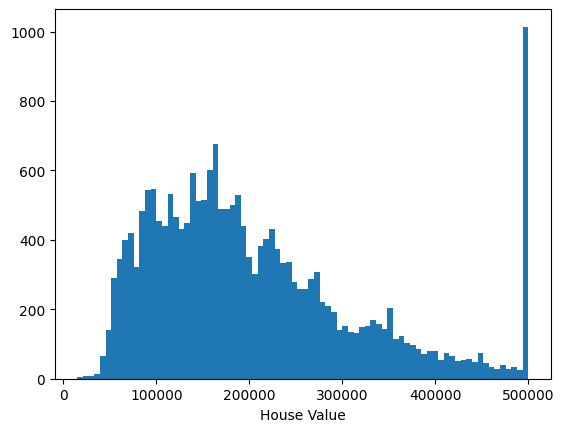

In [41]:
plt.hist(housing_df['median_house_value'], bins=80)
plt.xlabel('House Value')


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

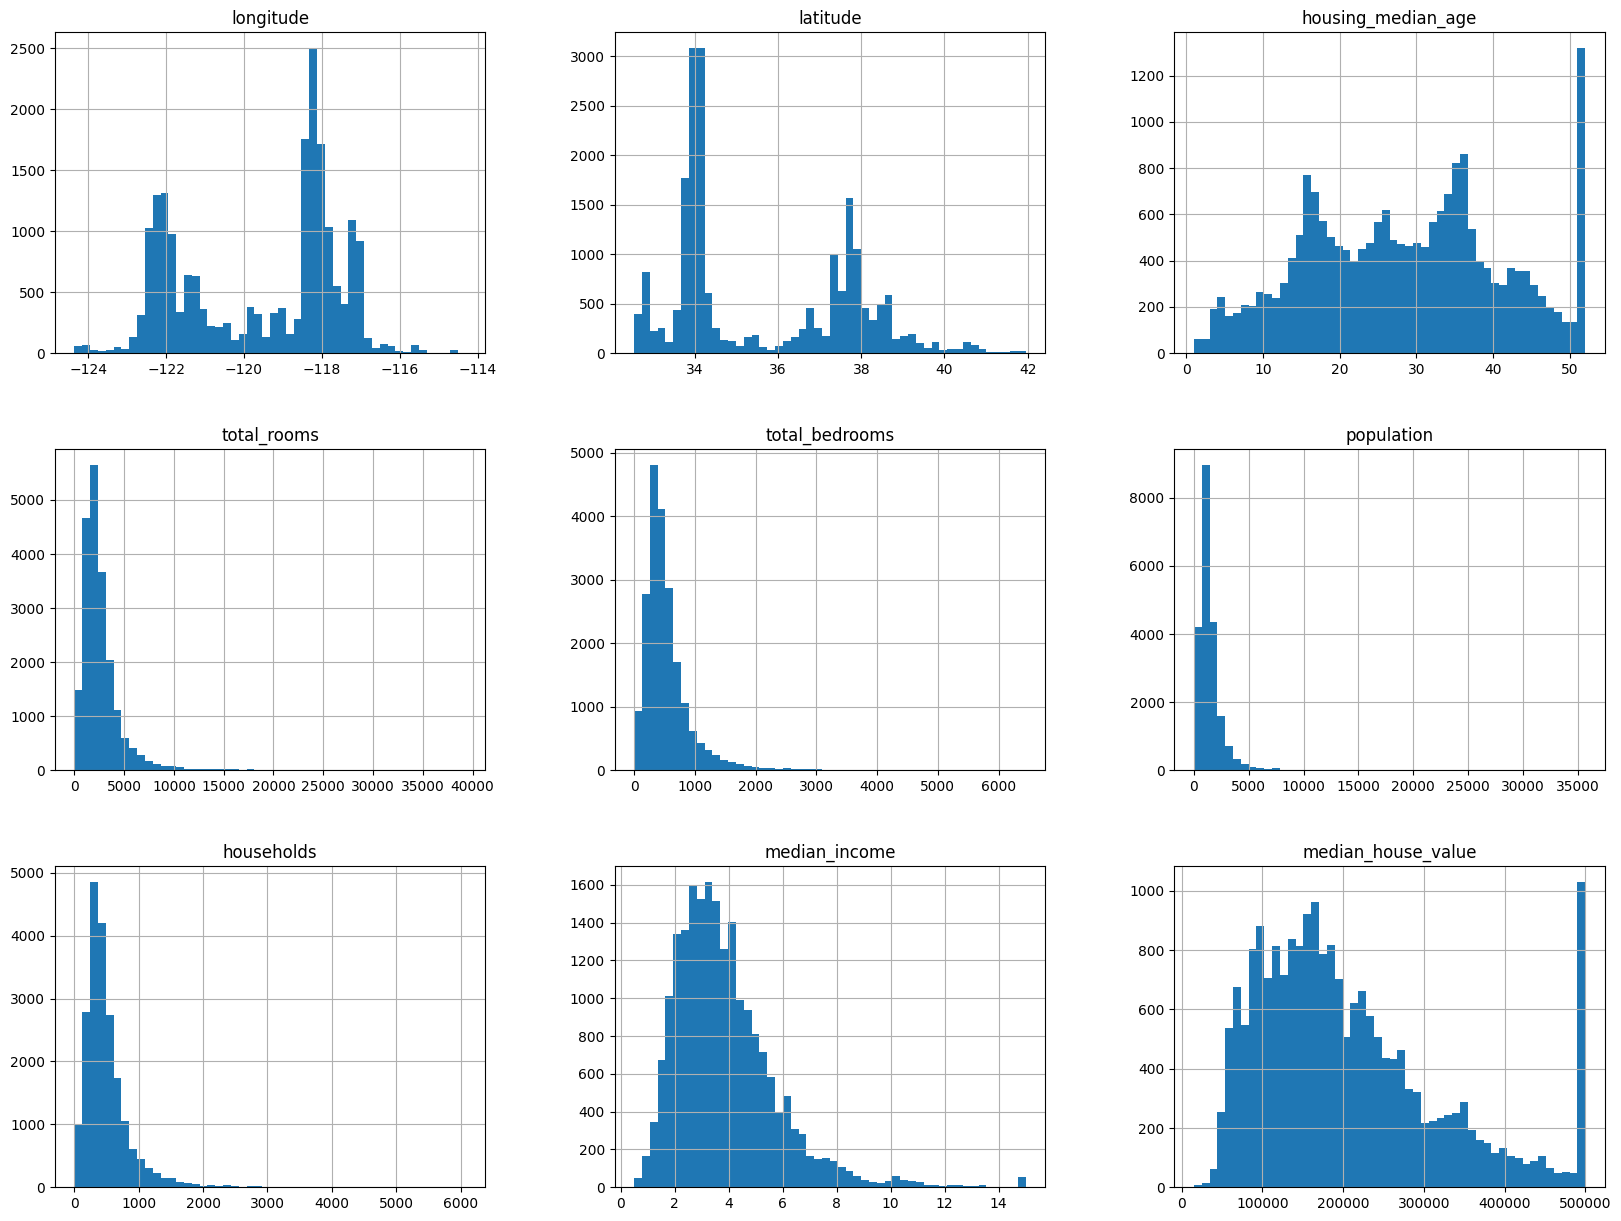

In [42]:
housing_df.hist(bins=50, figsize=(20,15))


In [43]:
corr=housing_df.drop('ocean_proximity', axis=1).corr()
print(corr)

                    longitude  latitude  housing_median_age  total_rooms  \
longitude            1.000000 -0.924664           -0.108197     0.044568   
latitude            -0.924664  1.000000            0.011173    -0.036100   
housing_median_age  -0.108197  0.011173            1.000000    -0.361262   
total_rooms          0.044568 -0.036100           -0.361262     1.000000   
total_bedrooms       0.069260 -0.066658           -0.318998     0.927253   
population           0.099773 -0.108785           -0.296244     0.857126   
households           0.055310 -0.071035           -0.302916     0.918484   
median_income       -0.015176 -0.079809           -0.119034     0.198050   
median_house_value  -0.045967 -0.144160            0.105623     0.134153   

                    total_bedrooms  population  households  median_income  \
longitude                 0.069260    0.099773    0.055310      -0.015176   
latitude                 -0.066658   -0.108785   -0.071035      -0.079809   
housing_

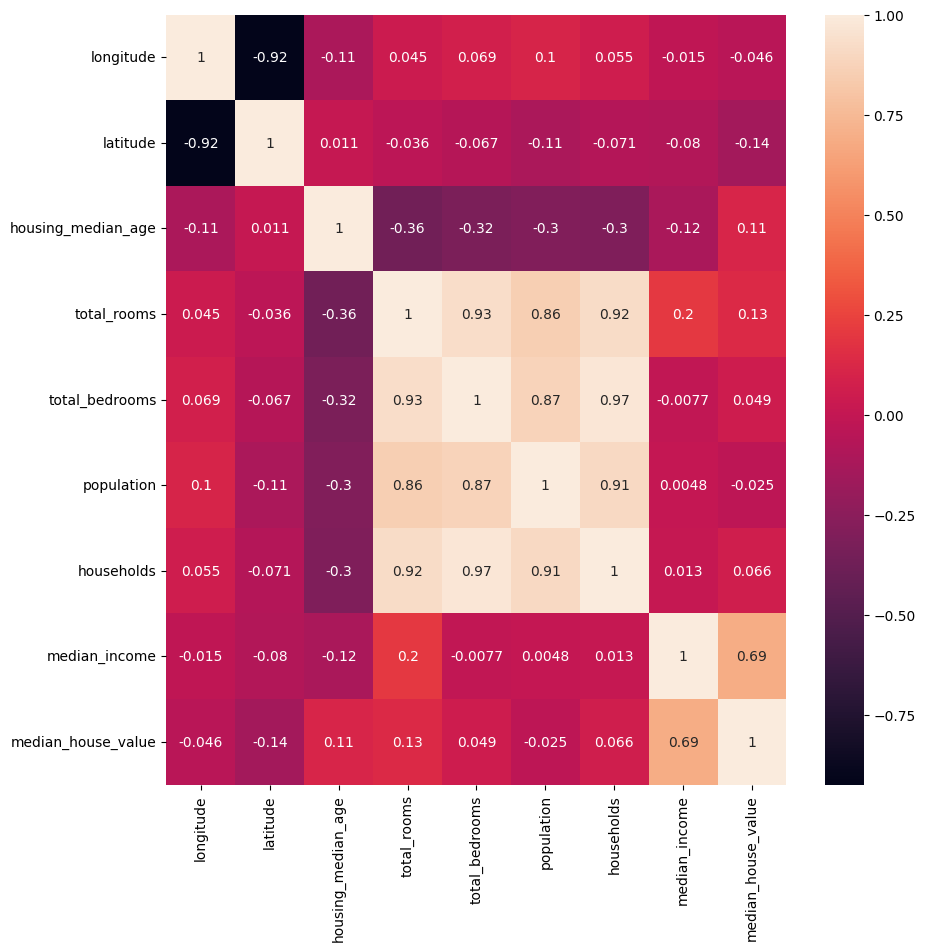

In [44]:
plt.figure(figsize=(10,10))
sns.heatmap(corr, annot=True)
plt.show()

## feature engineering

In [45]:
housing_df['room_per_household']=housing_df['total_rooms']/housing_df['households']
housing_df['bedrooms_per_room']=housing_df['total_bedrooms']/housing_df['total_rooms']
housing_df['population_per_household']=housing_df['population']/housing_df['households']
housing_df['coords']=housing_df['longitude']/housing_df['latitude']
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   longitude                 20640 non-null  float64
 1   latitude                  20640 non-null  float64
 2   housing_median_age        20640 non-null  float64
 3   total_rooms               20640 non-null  float64
 4   total_bedrooms            20640 non-null  float64
 5   population                20640 non-null  float64
 6   households                20640 non-null  float64
 7   median_income             20640 non-null  float64
 8   median_house_value        20640 non-null  float64
 9   ocean_proximity           20640 non-null  object 
 10  room_per_household        20640 non-null  float64
 11  bedrooms_per_room         20640 non-null  float64
 12  population_per_household  20640 non-null  float64
 13  coords                    20640 non-null  float64
dtypes: flo

In [46]:
housing_df=housing_df.drop('total_rooms', axis=1)
housing_df=housing_df.drop('total_bedrooms', axis=1)
housing_df=housing_df.drop('households', axis=1)
housing_df=housing_df.drop('population', axis=1)
housing_df=housing_df.drop('longitude', axis=1)
housing_df=housing_df.drop('latitude', axis=1)

housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   housing_median_age        20640 non-null  float64
 1   median_income             20640 non-null  float64
 2   median_house_value        20640 non-null  float64
 3   ocean_proximity           20640 non-null  object 
 4   room_per_household        20640 non-null  float64
 5   bedrooms_per_room         20640 non-null  float64
 6   population_per_household  20640 non-null  float64
 7   coords                    20640 non-null  float64
dtypes: float64(7), object(1)
memory usage: 1.3+ MB


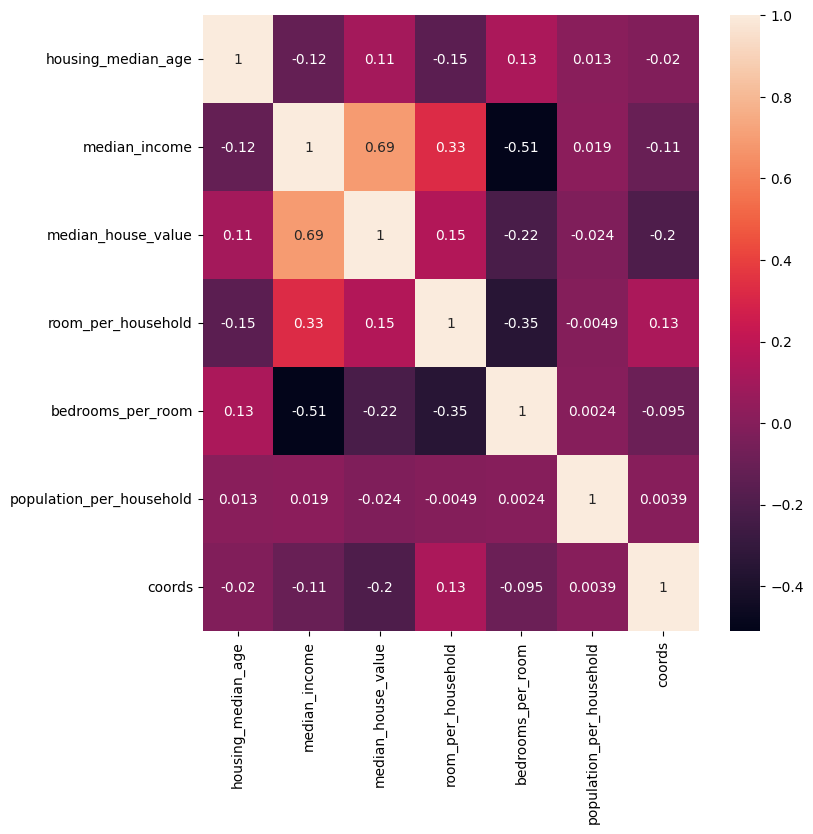

In [47]:
corr = housing_df.drop('ocean_proximity', axis=1).corr()
plt.figure(figsize=(8,8))
sns.heatmap(corr, annot=True)
plt.show()

In [48]:
housing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   housing_median_age        20640 non-null  float64
 1   median_income             20640 non-null  float64
 2   median_house_value        20640 non-null  float64
 3   ocean_proximity           20640 non-null  object 
 4   room_per_household        20640 non-null  float64
 5   bedrooms_per_room         20640 non-null  float64
 6   population_per_household  20640 non-null  float64
 7   coords                    20640 non-null  float64
dtypes: float64(7), object(1)
memory usage: 1.3+ MB


In [49]:
housing_df.ocean_proximity.unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [50]:
housing_df.ocean_proximity.value_counts()

,count
ocean_proximity,
<1H OCEAN,9136
INLAND,6551
NEAR OCEAN,2658
NEAR BAY,2290
ISLAND,5


In [51]:
print(pd.get_dummies(housing_df['ocean_proximity']))

       <1H OCEAN  INLAND  ISLAND  NEAR BAY  NEAR OCEAN
0          False   False   False      True       False
1          False   False   False      True       False
2          False   False   False      True       False
3          False   False   False      True       False
4          False   False   False      True       False
...          ...     ...     ...       ...         ...
20635      False    True   False     False       False
20636      False    True   False     False       False
20637      False    True   False     False       False
20638      False    True   False     False       False
20639      False    True   False     False       False

[20640 rows x 5 columns]


In [52]:
housing_df_encoded=pd.get_dummies(data=housing_df, columns=['ocean_proximity'])
housing_df_encoded.head()

,housing_median_age,median_income,median_house_value,room_per_household,bedrooms_per_room,population_per_household,coords,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,41.0,8.3252,452600.0,6.984127,0.146591,2.555556,-3.226769,False,False,False,True,False
1,21.0,8.3014,358500.0,6.238137,0.155797,2.109842,-3.228209,False,False,False,True,False
2,52.0,7.2574,352100.0,8.288136,0.129516,2.802260,-3.229590,False,False,False,True,False
3,52.0,5.6431,341300.0,5.817352,0.184458,2.547945,-3.229855,False,False,False,True,False
4,52.0,3.8462,342200.0,6.281853,0.172096,2.181467,-3.229855,False,False,False,True,False


## Spliting  Data into Training & Test Data

In [53]:
from sklearn.model_selection import train_test_split
X = housing_df_encoded.drop('median_house_value', axis=1)
y = housing_df_encoded['median_house_value']
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42,shuffle=True)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(14448, 11)
(6192, 11)
(14448,)
(6192,)


## Training the Model- Linear Model

In [54]:
from sklearn.linear_model import LinearRegression

reg_model=LinearRegression()
reg_model.fit(X_train,y_train)

LinearRegression()

In [55]:
# Predictions
y_pred=reg_model.predict(X_test)

## Evalute the model

In [56]:
pred_test_df=pd.DataFrame({'Actual':y_test,'Predicted':y_pred})
pred_test_df

,Actual,Predicted
20046,47700.0,104715.540790
3024,45800.0,90644.833269
15663,500001.0,215552.381354
20484,218600.0,283365.007591
9814,278000.0,245112.099874
...,...,...
17505,237500.0,209304.634501
13512,67300.0,74640.438821
10842,218400.0,215452.143080
16559,119400.0,125811.202747


In [57]:
# R^2 evalute model
from sklearn.metrics import r2_score
r2_reg_model_test=round(reg_model.score(X_test,y_test),2)
print("R^2 Test:{}".format(r2_reg_model_test*100))

R^2 Test:55.00000000000001


## Training the Model- Randdom Forest

In [58]:
from sklearn.ensemble import RandomForestRegressor

rf_model=RandomForestRegressor(n_estimators=10,random_state=10)
rf_model.fit(X_train,y_train)

RandomForestRegressor(n_estimators=10, random_state=10)

In [59]:
# Run the preditions
y_rf_pred_test=rf_model.predict(X_test)

In [60]:
# Evalute the Model
y_rf_pred_test_df=pd.DataFrame({'Actual':y_test,'Predicted':y_rf_pred_test})
y_rf_pred_test_df

,Actual,Predicted
20046,47700.0,53510.0
3024,45800.0,96990.0
15663,500001.0,442670.3
20484,218600.0,259180.0
9814,278000.0,246620.0
...,...,...
17505,237500.0,241580.1
13512,67300.0,72000.0
10842,218400.0,202330.0
16559,119400.0,129890.0


In [61]:
# R^2 evalute
from sklearn.metrics import r2_score
score=r2_score(y_test,y_rf_pred_test)
print("R^2-{}%".format(round(score,2)*100))

R^2-76.0%


## Actual vs Predicted

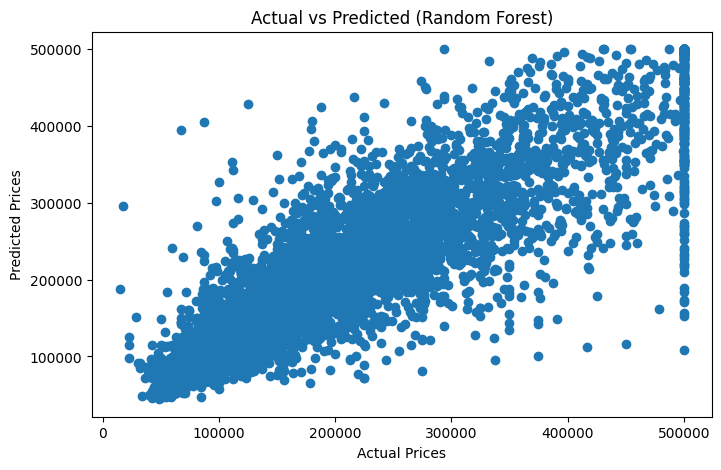

In [63]:
plt.figure(figsize=(8,5))
plt.scatter(y_test,y_rf_pred_test)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

## Important Feature

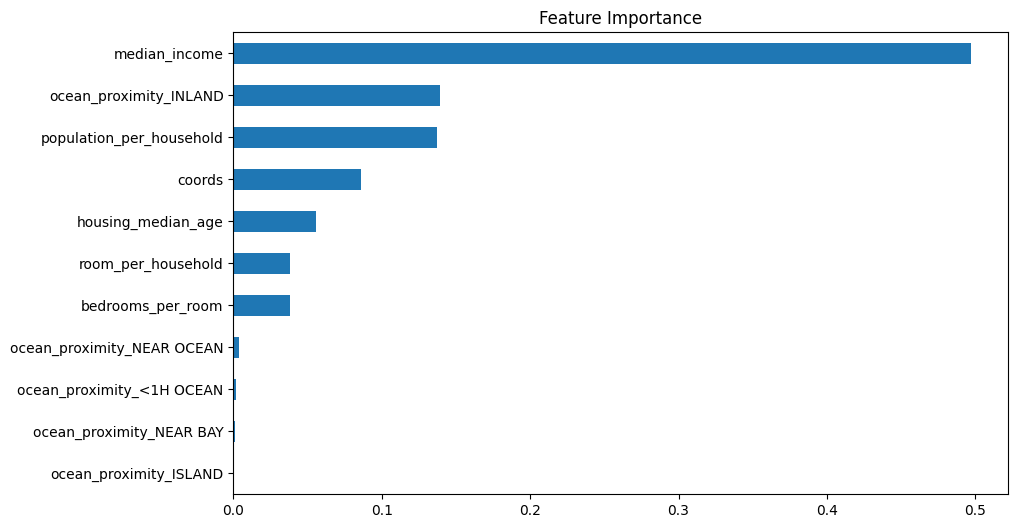

In [66]:
importance = pd.Series(rf_model.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh', figsize=(10,6))
plt.title("Feature Importance")
plt.show()